In [1]:
import torch

# t_c values are temperatures in Celsius
# t_u values are unknown units
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]
t_c = torch.tensor(t_c)
t_u = torch.tensor(t_u)

In [2]:
# use the simplest possible model
# t_c = w * t_u + b


# taking the difference between the desired outputs for some training samples 
# and the outputs actually produced by the model when fed some samples

# t_p - t_c
# |t_p - t_c|   (t_p - t_c) ^ 2
# Based on the mathematical expression we choose, we can emphasize or dicount certain errors
# Conceptually, a loss function is a way of prioritizing which errors to fix from our training 
# samples

In [3]:
def model(t_u, w, b):
    return w * t_u + b

In [4]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

In [5]:
w = torch.ones(())
b = torch.zeros(())

t_p = model(t_u, w, b)
t_p

tensor([35.7000, 55.9000, 58.2000, 81.9000, 56.3000, 48.9000, 33.9000, 21.8000,
        48.4000, 60.4000, 68.4000])

In [6]:
# check the loss
loss = loss_fn(t_p, t_c)
loss

tensor(1763.8848)

In [7]:
delta = 0.1
# 改变 w 对损失函数的影响 / 梯度
loss_rate_of_change_w = (loss_fn(model(t_u, w + delta, b), t_c) -
                         loss_fn(model(t_u, w - delta, b), t_c)) / (2.0 * delta)

In [8]:
learning_rate = 1e-2
w = w - learning_rate * loss_rate_of_change_w

In [9]:
loss_rate_of_change_b = (loss_fn(model(t_u, w, b + delta), t_c) - 
                         loss_fn(model(t_u, w, b - delta), t_c)) / (2.0 * delta)
b = b - learning_rate * loss_rate_of_change_b

$\frac{dloss\_dn}{dw}$ = $\frac{dloss\_fn}{dt_p}$ * $\frac{dt_p}{dw}$

**损失函数**<br><br>
L = $\frac{1}{n}\sum_{i=1}^{n}(t_{p_i}-t_{c_i})^2$

$\frac{\partial L}{\partial t_{p_i}} = \frac{\partial}{\partial t_{p_i}}\frac{1}{n}\sum_{j=1}^{n}(t_{p_j}-t_{c_j})^2$
<br><br>&emsp;&emsp;
=$\frac{1}{n}\frac{\partial}{\partial t_{p_i}}(t_{p_i} - t_{c_i})^2$
<br><br>&emsp;&emsp;
=$\frac{1}{n}*2(t_{p_i}-t_{c_i})$

In [10]:
def dloss_fn(t_p, t_c):
    dsq_diffs = 2 * (t_p - t_c) / t_p.size(0)
    return dsq_diffs

In [11]:
def dmodel_dw(t_u, w, b):
    return t_u

In [12]:
def dmodel_db(t_u, w, b):
    return 1.0

In [21]:
# 梯度
def grad_fn(t_u, t_c, t_p, w, b):
    dloss_dtp = dloss_fn(t_p, t_c)
    dloss_dw = dloss_dtp * dmodel_dw(t_u, w, b)
    dloss_db = dloss_dtp * dmodel_db(t_u, w, b)
    return torch.stack([dloss_dw.sum(), dloss_db.sum()])

In [20]:
def training_loop(n_epochs, learning_rate, params, t_u, t_c):
    for epoch in range(1, n_epochs + 1):
        w, b = params
        t_p = model(t_u, w, b)
        loss = loss_fn(t_p, t_c)
        grad = grad_fn(t_u, t_c, t_p, w, b)
        
        params = params - learning_rate * grad
        print('Epoch %d, Loss %f' % (epoch, float(loss)))
    
    return params

In [26]:
# 归一化，不让均值偏差太多
t_un = 0.1 * t_u
params = training_loop(
    n_epochs=5000, 
    learning_rate=1e-2,
    params=torch.tensor([1.0, 0.0]),
    t_u=t_un,
    t_c=t_c
)

Epoch 1, Loss 80.364342
Epoch 2, Loss 37.574913
Epoch 3, Loss 30.871077
Epoch 4, Loss 29.756193
Epoch 5, Loss 29.507153
Epoch 6, Loss 29.392456
Epoch 7, Loss 29.298828
Epoch 8, Loss 29.208717
Epoch 9, Loss 29.119415
Epoch 10, Loss 29.030489
Epoch 11, Loss 28.941877
Epoch 12, Loss 28.853565
Epoch 13, Loss 28.765553
Epoch 14, Loss 28.677851
Epoch 15, Loss 28.590431
Epoch 16, Loss 28.503319
Epoch 17, Loss 28.416498
Epoch 18, Loss 28.329973
Epoch 19, Loss 28.243742
Epoch 20, Loss 28.157804
Epoch 21, Loss 28.072151
Epoch 22, Loss 27.986797
Epoch 23, Loss 27.901728
Epoch 24, Loss 27.816950
Epoch 25, Loss 27.732464
Epoch 26, Loss 27.648256
Epoch 27, Loss 27.564344
Epoch 28, Loss 27.480707
Epoch 29, Loss 27.397362
Epoch 30, Loss 27.314295
Epoch 31, Loss 27.231512
Epoch 32, Loss 27.149010
Epoch 33, Loss 27.066790
Epoch 34, Loss 26.984844
Epoch 35, Loss 26.903175
Epoch 36, Loss 26.821791
Epoch 37, Loss 26.740679
Epoch 38, Loss 26.659838
Epoch 39, Loss 26.579279
Epoch 40, Loss 26.498987
Epoch 41,

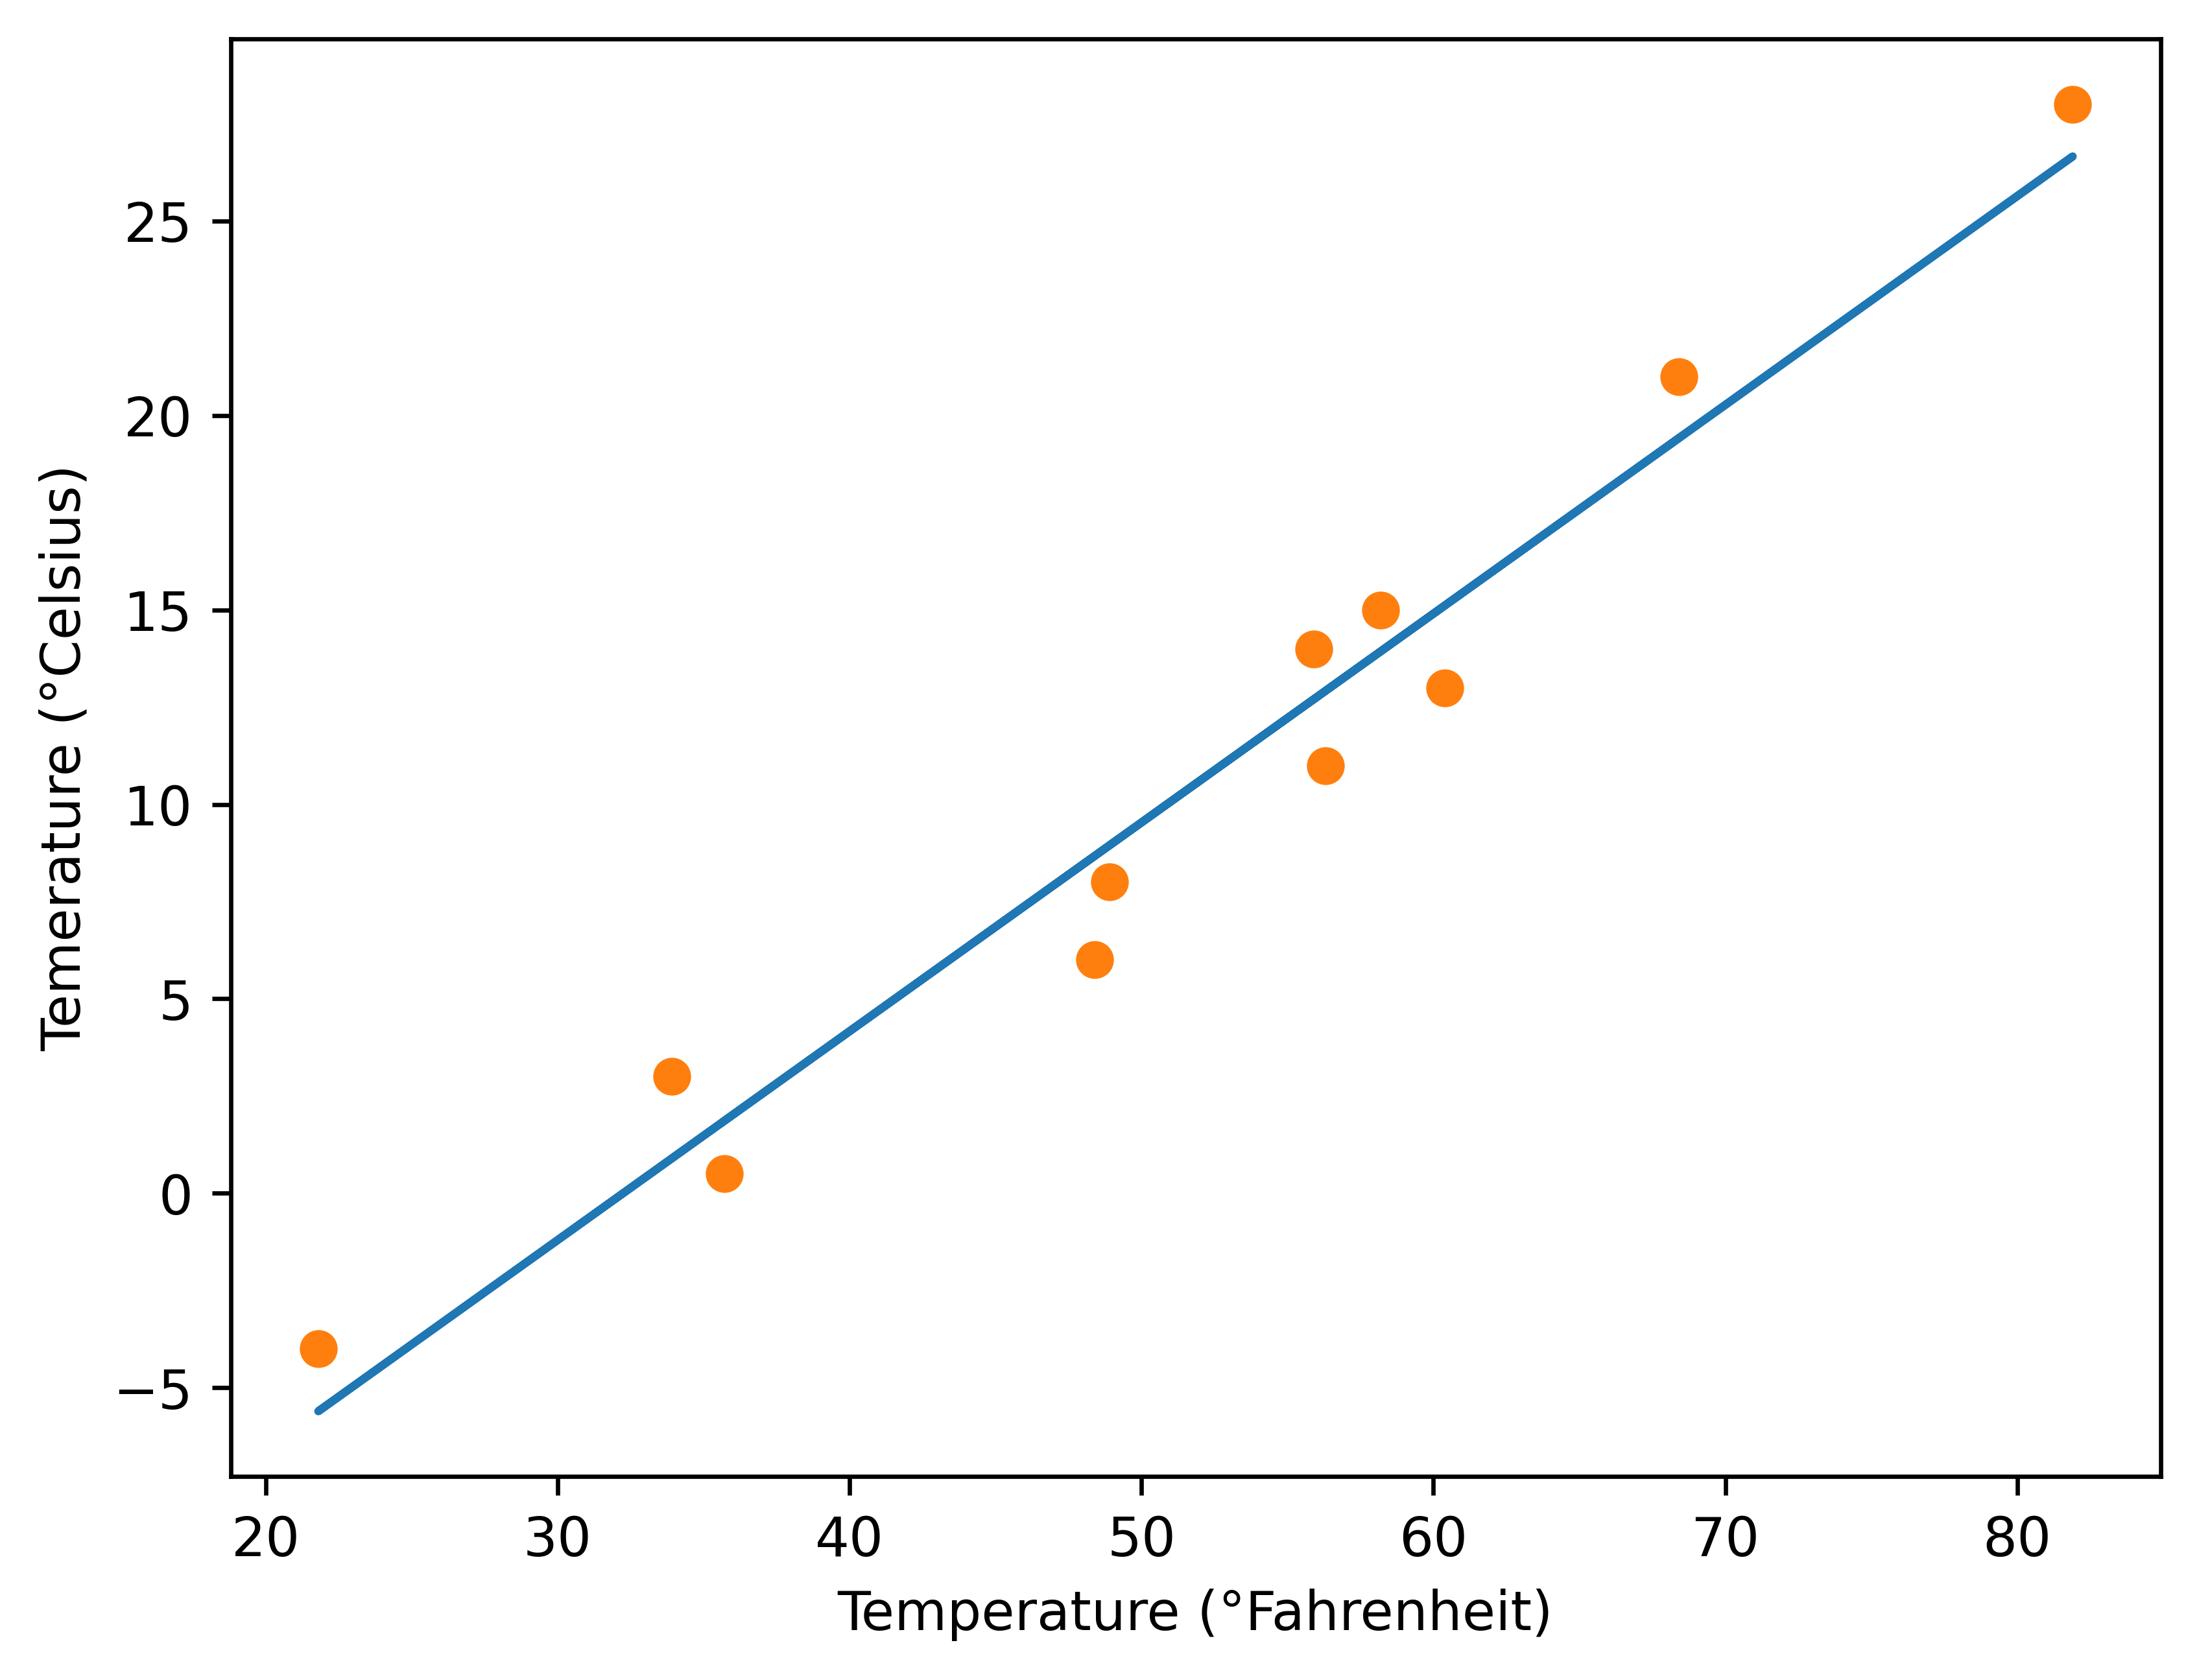

In [30]:
# visualizing
%matplotlib inline
from matplotlib import pyplot as plt

t_p = model(t_un, *params)
fig = plt.figure(dpi=600)
plt.xlabel("Temperature (°Fahrenheit)")
plt.ylabel("Temerature (°Celsius)")
plt.plot(t_u.numpy(), t_p.detach().numpy())
plt.plot(t_u.numpy(), t_c.numpy(), 'o')